# Building a Site Archive

A key element of the the PyEarthTools user experience is enabling a central repository or catalogue of data that is specific to the site or platform in questions. This abstracts away the details of how the data is stored and organised for a particular site and instead providing a consistent interface to the data. Platform managers and data curators can optimse the storage and loading of the data for the specifics of the platform without requiring additional training for the users of the data.  This tutorial is aimed at those who would like to create a new site archive for their particular platform. The tutorial builds on the [Building an Accessor tutorial](BuildingAnAccessor.ipynb) tutorial.

## Components of A Site Archive

There are a few components that typically go into 

* Paths to datasets - These done have to all be in the same location, though typically all on the same platform.
* Dataset Accessors - For each of the datasets to be included in the site archive, there should be an accessor.
  * This doesn't have to be a bespoke accessor, so long as it is is suitably parameterised to be able to adapt to the target platform. For example, one could use the same ERA5 accessor for several sites, so long as the root directory of the data is passed as a parameter and the organisation of the data on disk is the same.
  * Accessors should include call to the `register_archive` function so that they can be accessed through the `pyearthtools.data.archive
* A list of accessors - This is included


In [1]:
import site_archive_aws

ROOT_DIRECTORIES: {'MOGlobal10km': 's3://met-office-atmospheric-model-data/global-deterministic/', 'MOUKV_AWS': 's3://met-office-atmospheric-model-data/uk-deterministic/'}


In [2]:
import pyearthtools.data.archive

In [3]:
dir(pyearthtools.data.archive)

['ERA5_ARCO',
 'MOGlobal10km',
 'MOUKV',
 'ROOT_DIRECTORIES',
 'ZarrIndex',
 'ZarrTimeIndex',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'aws',
 'config_root',
 'extensions',
 'get_indexes',
 'get_root_directories',
 'load_root_directories_from_config',
 'print_indexes',
 'pyearthtools',
 'register_archive',
 'registered',
 'reset_root',
 'root',
 'set_root',
 'set_root_directory',
 'sys',
 'utils',
 'zarr']

In [4]:
var_list = [
    'temperature_on_pressure_levels',
    'relative_humidity_on_pressure_levels',
    'wind_speed_on_pressure_levels',
    'wind_direction_on_pressure_levels',
]

In [5]:
ukv_accessor = pyearthtools.data.archive.MOUKV(var_list)

In [6]:
sample_data_ukv = ukv_accessor['2026-03-01 13:00']

['s3://met-office-atmospheric-model-data/uk-deterministic-2km/20260301T1300Z/20260301T1300Z-PT0000H00M-temperature_on_pressure_levels.nc', 's3://met-office-atmospheric-model-data/uk-deterministic-2km/20260301T1300Z/20260301T1300Z-PT0000H00M-relative_humidity_on_pressure_levels.nc', 's3://met-office-atmospheric-model-data/uk-deterministic-2km/20260301T1300Z/20260301T1300Z-PT0000H00M-wind_speed_on_pressure_levels.nc', 's3://met-office-atmospheric-model-data/uk-deterministic-2km/20260301T1300Z/20260301T1300Z-PT0000H00M-wind_direction_on_pressure_levels.nc']


/home/users/shaddad/prog/pet_fork/packages/third_party/aws_site_archive/src/site_archive_aws/mo_ukv.py:74: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xarray.merge([xarray.open_dataset(path1, **self._open_args) for path1 in args[0]])
/home/users/shaddad/prog/pet_fork/packages/third_party/aws_site_archive/src/site_archive_aws/mo_ukv.py:74: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the 

In [7]:
sample_data_ukv

<xarray.Dataset> Size: 567MB
Dimensions:                       (time: 1, pressure: 33,
                                   projection_y_coordinate: 970,
                                   projection_x_coordinate: 1042, bnds: 2)
Coordinates:
  * time                          (time) datetime64[ns] 8B 2026-03-01T13:00:00
  * pressure                      (pressure) float32 132B 1e+05 ... 1e+03
  * projection_y_coordinate       (projection_y_coordinate) float32 4kB -1.03...
  * projection_x_coordinate       (projection_x_coordinate) float32 4kB -1.15...
    forecast_period               timedelta64[ns] 8B 00:00:00
    forecast_reference_time       datetime64[ns] 8B 2026-03-01T13:00:00
Dimensions without coordinates: bnds
Data variables:
    air_temperature               (time, pressure, projection_y_coordinate, projection_x_coordinate) float32 133MB ...
    lambert_azimuthal_equal_area  (time) int32 4B -2147483647
    projection_y_coordinate_bnds  (time, projection_y_coordinate, bnds) float32 8kB ...
    projection_x_coordinate_bnds  (time, projection_x_coordinate, bnds) float32 8kB ...
    flag                          (time, pressure, projection_y_coordinate, projection_x_coordinate) int8 33MB ...
    relative_humidity             (time, pressure, projection_y_coordinate, projection_x_coordinate) float32 133MB ...
    wind_speed                    (time, pressure, projection_y_coordinate, projection_x_coordinate) float32 133MB ...
    wind_from_direction           (time, pressure, projection_y_coordinate, projection_x_coordinate) float32 133MB ...
Attributes:
    ancillary_variables:          flag
    history:                      2026-03-01T14:05:56Z: StaGE Decoupler
    institution:                  Met Office
    mosg__forecast_run_duration:  PT12H
    mosg__grid_domain:            uk_extended
    mosg__grid_type:              standard
    mosg__grid_version:           1.7.0
    mosg__model_configuration:    uk_det
    source:                       Met Office Unified Model
    title:                        UKV Model Forecast on UK 2 km Standard Grid
    um_version:                   13.8
    Conventions:                  CF-1.7, UKMO-1.0

In [8]:
import matplotlib.pyplot
import cartopy

In [9]:
data_projection = cartopy.crs.LambertAzimuthalEqualArea(central_latitude=54.9, central_longitude=-2.5, false_easting=0.0, false_northing=0.0)

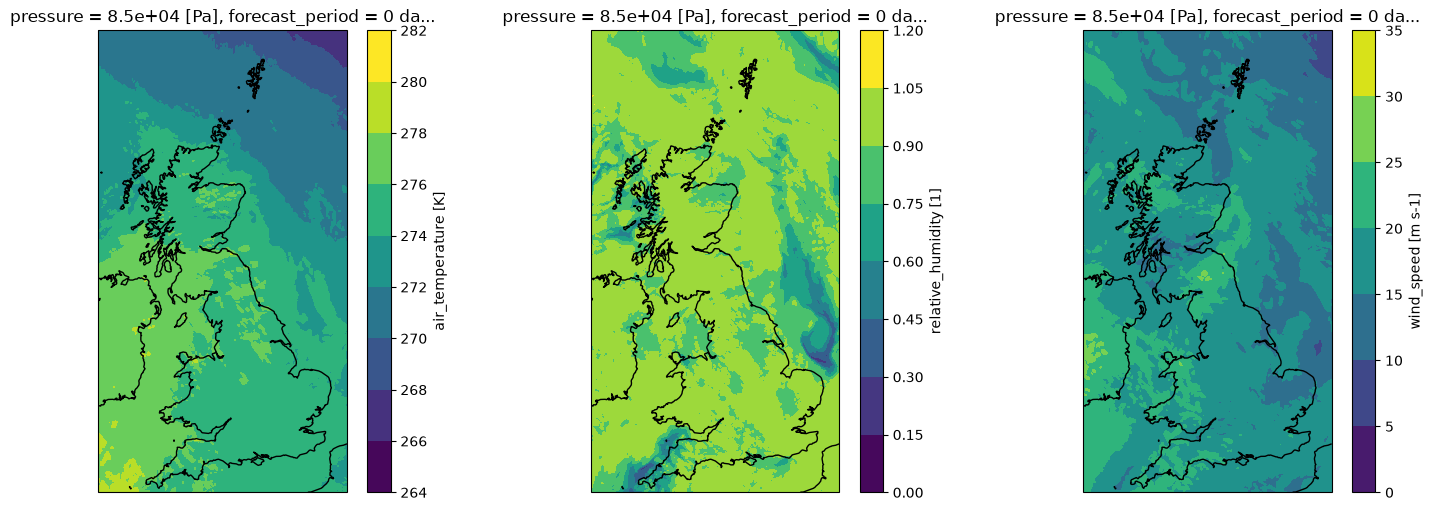

In [10]:
fig1 = matplotlib.pyplot.figure(figsize=(18,6))
# plot temperature at 850hpa pressure level
ax1 = fig1.add_subplot(1,3,1,projection=cartopy.crs.OSGB() )
sample_data_ukv.sel({'pressure':85000})['air_temperature'][0].plot.contourf(
    ax=ax1,
    transform=data_projection,
)
ax1.coastlines()


ax1 = fig1.add_subplot(1,3,2,projection=cartopy.crs.OSGB() )

sample_data_ukv.sel({'pressure':85000})['relative_humidity'][0].plot.contourf(
    ax=ax1,
    transform=data_projection,
)
ax1.coastlines()

ax1 = fig1.add_subplot(1,3,3,projection=cartopy.crs.OSGB() )
sample_data_ukv.sel({'pressure':85000})['wind_speed'][0].plot.contourf(
    ax=ax1,
    transform=data_projection,
)
ax1.coastlines()


### Loading Global data

In [11]:
moglobal_accessor = pyearthtools.data.archive.MOGlobal10km(var_list)

In [12]:
sample_data_moglobal = moglobal_accessor['2026-03-01 13:00']

['s3://met-office-atmospheric-model-data/global-deterministic-10km/20260301T1300Z/20260301T1300Z-PT0000H00M-temperature_on_pressure_levels.nc', 's3://met-office-atmospheric-model-data/global-deterministic-10km/20260301T1300Z/20260301T1300Z-PT0000H00M-relative_humidity_on_pressure_levels.nc', 's3://met-office-atmospheric-model-data/global-deterministic-10km/20260301T1300Z/20260301T1300Z-PT0000H00M-wind_speed_on_pressure_levels.nc', 's3://met-office-atmospheric-model-data/global-deterministic-10km/20260301T1300Z/20260301T1300Z-PT0000H00M-wind_direction_on_pressure_levels.nc']


DataNotFoundError: Data with args: (Petdt('2026-03-01T13:00'),) could not be found.

In [ ]:
sample_data_ukv

In [ ]:
# demonstrate an accessor

In [ ]:
# register the site archive


In [ ]:
# demonstrate loading the data through the data.archive route and visualising